In [ ]:
import pandas as pd
import numpy as np
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import sma, ema, rolling_volatility, simple_returns, log_returns
from quant_lab.strategies.sma_crossover import ma_crossover_position
from quant_lab.strategies.donchain_breakout import donchian_breakout_position
from quant_lab.engine.backtest import backtest_log_returns
import matplotlib.pyplot as plt 
from quant_lab.metrics.performance import evaluate_performance
from quant_lab.metrics.trades import generate_trade_log

df = load_prices("AAPL", "2023-06-01", "2026-03-01")
close = df["Close"]

if isinstance(close, pd.DataFrame): # converts single column dataframe to series
    close = close.iloc[1:, 0]

df['SIMPLE_RETURNS'] = simple_returns(close)
df['LOG_RETURNS'] = log_returns(close)
df['SMA_20'] = sma(close, window=20)
df['EMA_20'] = ema(close, span=20)
df["VOL_20"] = rolling_volatility(df["LOG_RETURNS"], window=20)

df[['Close', 'SMA_20', 'EMA_20']].plot(title='FTSE Closing Price with SMA and EMA')
plt.show()

print(type(close))
print(close.head())
position = donchian_breakout_position(close, lookback=20)

# Backtest with and without borrow costs
bt_no_borrow = backtest_log_returns(close, position, cost_per_trade=0.001)
bt_with_borrow = backtest_log_returns(close, position, cost_per_trade=0.001, borrow_cost=0.02)  # 2% annual borrow cost

print("\n--- Position Analysis ---")
print(position.value_counts())  # Count of each position type (-1, 0, 1)
print(f"Percentage of time SHORT: {(position == -1).sum() / len(position) * 100:.2f}%")
print(f"Percentage of time LONG: {(position == 1).sum() / len(position) * 100:.2f}%")

buy_hold_equity = np.exp(np.cumsum(log_returns(close)))  # Buy and hold equity curve

print("\n--- Performance Comparison ---")
print(f"Strategy final equity (no borrow): {bt_no_borrow['equity'].iloc[-1]:.4f}")
print(f"Strategy final equity (with borrow): {bt_with_borrow['equity'].iloc[-1]:.4f}")
print(f"Buy & hold final equity: {buy_hold_equity.iloc[-1]:.4f}")
print(f"Total trades executed: {bt_no_borrow['trade'].sum():.0f}")
print(f"Max Drawdown (no borrow): {bt_no_borrow['drawdown'].min()*100:.2f}%")
print(f"Max Drawdown (with borrow): {bt_with_borrow['drawdown'].min()*100:.2f}%")

print(generate_trade_log(bt_no_borrow))

plt.figure(figsize=(12, 6))
plt.plot(bt_no_borrow["equity"], label="MA Strategy (no borrow cost)", linewidth=2)
plt.plot(bt_with_borrow["equity"], label="MA Strategy (2% borrow cost)", linewidth=2)
plt.plot(buy_hold_equity, label="Buy & Hold", linewidth=2)
plt.legend()
plt.title("Strategy vs Buy & Hold (With and Without Borrow Costs)")
plt.ylabel("Equity")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()

# plt.figure(figsize=(12, 6))
# plt.plot(bt_no_borrow["drawdown"]*100, label="MA Strategy (no borrow cost)", linewidth=2)
# plt.plot(bt_with_borrow["drawdown"]*100, label="MA Strategy (2% borrow cost)", linewidth=2)
# plt.legend()
# plt.title("Drawdown Comparison")
# plt.ylabel("Drawdown (%)")
# plt.xlabel("Date")
# plt.grid(True, alpha=0.3)
# plt.show()

print("\n--- Performance Metrics (No Borrow Cost) ---")
print(evaluate_performance(bt_no_borrow))
print("\n--- Performance Metrics (With Borrow Cost) ---")
print(evaluate_performance(bt_with_borrow))

print(position.value_counts())
print(position.head(30))
print(bt_no_borrow[['close', 'position', 'position_shifted', 'log_return', 'strat_log']].head(30))
print(bt_no_borrow['strat_log'].isna().sum(), "NaN strat_log values")
print(bt_no_borrow['equity'].isna().sum(), "NaN equity values")

print(bt_no_borrow[bt_no_borrow['position'] != bt_no_borrow['position'].shift(1)][['close','position']].head(20))


In [ ]:
import pandas as pd
import numpy as np
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import sma, ema, rolling_volatility, simple_returns, log_returns
from quant_lab.strategies.sma_crossover import ma_crossover_position
from quant_lab.strategies.donchain_breakout import donchian_breakout_position
from quant_lab.engine.backtest import backtest_log_returns
import matplotlib.pyplot as plt 
from quant_lab.metrics.performance import evaluate_performance
from quant_lab.metrics.trades import generate_trade_log

df = load_prices("AAPL", "2023-06-01", "2026-03-01")
close = df["Close"]

if isinstance(close, pd.DataFrame): # converts single column dataframe to series
    close = close.iloc[1:, 0]

print(type(close))
print(close.head())
# for lb in [10, 20, 40, 60]:
#     position = donchian_breakout_position(close, lookback=lb, threshold=0.0)
#     bt = backtest_log_returns(close, position, cost_per_trade=0.001)
#     print(f"lookback={lb}  return={bt['strat_log'].sum():.3f}  trades={bt['trade'].sum():.0f}")

# position = donchian_breakout_position(close, lookback=40, threshold=0.0)
# bt = backtest_log_returns(close, position, cost_per_trade=0.001)
# print(f"Donchian Breakout Strategy (lookback=40)  return={bt['strat_log'].sum():.3f}  trades={bt['trade'].sum():.0f}")

# position_long_only = position.clip(lower=0)  # Convert to long-only by setting short positions to 0
# bt_long_only = backtest_log_returns(close, position_long_only, cost_per_trade=0.001)

for ticker in ["AAPL", "SPY"]:
    close = load_prices(ticker, "2023-06-01", "2026-03-01")["Close"]

    if isinstance(close, pd.DataFrame):
        close = close.iloc[1:, 0]

    position = donchian_breakout_position(close, lookback=10, threshold=0.05)
    bt = backtest_log_returns(close, position, cost_per_trade=0.001)
    print(f"{ticker} Donchian Breakout Strategy (lookback=10, threshold=0.05)  return={bt['strat_log'].sum():.3f}  trades={bt['trade'].sum():.0f}")

    buy_hold_equity = np.exp(np.cumsum(log_returns(close)))  # Buy and hold equity curve

    plt.figure(figsize=(12, 6))
    plt.plot(bt["equity"], label=f"{ticker} Donchian Breakout Equity", linewidth=2)
    plt.plot(buy_hold_equity, label=f"{ticker} Buy & Hold Equity", linewidth=2)
    plt.title(f"{ticker} Donchian Breakout Strategy Equity Curve")
    plt.ylabel("Equity")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n Performance Metrics ---")
    print(evaluate_performance(bt))

    print(position.value_counts())
    print(position.head(30))
    print(bt[['close', 'position', 'position_shifted', 'log_return', 'strat_log']].head(30))
    print(bt['strat_log'].isna().sum(), "NaN strat_log values")
    print(bt['equity'].isna().sum(), "NaN equity values")

    print("\n Trade Log ---")
    tl = generate_trade_log(bt, vol_window=20, trend_window=20)
    print(tl)

    

In [ ]:
import pandas as pd
import numpy as np
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import log_returns
from quant_lab.strategies.sma_crossover import ma_crossover_position
from quant_lab.engine.backtest import backtest_log_returns
from quant_lab.metrics.performance import evaluate_performance
from quant_lab.metrics.trades import generate_trade_log
import matplotlib.pyplot as plt

windows = [
    (fast, slow)
    for fast in range(10, 51, 5)
    for slow in range(20, 101, 5)
    if slow > fast
]
results = []

for ticker in ["SPY"]:
    close = load_prices(ticker, "2023-06-01", "2026-03-01")["Close"]

    if isinstance(close, pd.DataFrame):
        close = close.iloc[1:, 0]

    buy_hold_equity = np.exp(log_returns(close).cumsum())

    for fast, slow in windows:

        pos_ma       = ma_crossover_position(close, fast_window=fast, slow_window=slow)
        pos_donchian = donchian_breakout_position(close, lookback=40)

        position = np.where((pos_donchian == 1)  & (pos_ma == 1),  1,
        np.where((pos_donchian == -1) & (pos_ma == -1), -1, 0))
        position = pd.Series(position, index=close.index, dtype=float)

        bt = backtest_log_returns(close, position, cost_per_trade=0.001)
        perf = evaluate_performance(bt)

        results.append({
            'Ticker':    ticker,
            'Fast':      fast,
            'Slow':      slow,
            'Return':    perf['Total Return'],
            'Sharpe':    perf['Sharpe Ratio'],
            'Drawdown':  perf['Max Drawdown'],
            'Trades':    perf['Total Trades Executed'],
        })

# Build results table
results_df = pd.DataFrame(results).sort_values('Sharpe', ascending=False)
print("\n--- All Results (sorted by Sharpe) ---")
print(results_df.to_string(index=False))

print("\n--- Filtered Results (Drawdown > -20%, Sharpe > 0.5, Positive Return) ---")
filtered = results_df[
    (results_df["Drawdown"] > -0.20) &
    (results_df["Sharpe"]   >  0.50) &
    (results_df["Return"]   >  0.00)
].sort_values("Sharpe", ascending=False)

if filtered.empty:
    print("No combinations met the filter criteria — consider relaxing the thresholds")
else:
    print(filtered.to_string(index=False))
# ---- END ----

# Best by Sharpe (from filtered if available, otherwise full results)
best_pool = filtered if not filtered.empty else results_df
best = best_pool.iloc[0]
print(f"\n--- Best Combination ---")
print(f"Ticker: {best['Ticker']}  Fast: {int(best['Fast'])}  Slow: {int(best['Slow'])}")
print(f"Sharpe: {best['Sharpe']:.3f}  Return: {best['Return']:.3f}  Drawdown: {best['Drawdown']:.3f}")

# Plot the best
close = load_prices(best['Ticker'], "2023-06-01", "2026-03-01")["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[1:, 0]



pos_ma       = ma_crossover_position(close, fast_window=best['Fast'], slow_window=best['Slow'])
pos_donchian = donchian_breakout_position(close, lookback=40)

position = np.where((pos_donchian == 1)  & (pos_ma == 1),  1,
           np.where((pos_donchian == -1) & (pos_ma == -1), -1, 0))
position = pd.Series(position, index=close.index, dtype=float)

bt = backtest_log_returns(close, position, cost_per_trade=0.001)
buy_hold_equity = np.exp(log_returns(close).cumsum())

plt.figure(figsize=(12, 6))
plt.plot(bt["equity"], label=f"MA Crossover (fast={int(best['Fast'])}, slow={int(best['Slow'])})", linewidth=2)
plt.plot(buy_hold_equity, label="Buy & Hold", linewidth=2)
plt.title(f"{best['Ticker']} Best MA Crossover Strategy")
plt.ylabel("Equity")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# top ten drawdown-filtered by Sharpe (or overall if none passed filters)

top10 = filtered.head(10) if not filtered.empty else results_df.head(10)

plt.figure(figsize=(12, 6))

for _, row in top10.iterrows():
    close = load_prices(row['Ticker'], "2023-06-01", "2026-03-01")["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[1:, 0]

    pos_ma       = ma_crossover_position(close, fast_window=best['Fast'], slow_window=best['Slow'])
    pos_donchian = donchian_breakout_position(close, lookback=40)

    position = np.where((pos_donchian == 1)  & (pos_ma == 1),  1,
               np.where((pos_donchian == -1) & (pos_ma == -1), -1, 0))
    position = pd.Series(position, index=close.index, dtype=float)
    
    bt = backtest_log_returns(close, position, cost_per_trade=0.001)

    label = f"{row['Ticker']} ({int(row['Fast'])}/{int(row['Slow'])}) Sharpe={row['Sharpe']:.2f}"
    plt.plot(bt["drawdown"] * 100, label=label, linewidth=1.5)

plt.legend(fontsize=8)
plt.title("Drawdown — Top 10 MA Crossover Combinations")
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# top ten equity curves

top10 = filtered.head(10) if not filtered.empty else results_df.head(10)

plt.figure(figsize=(12, 6))

for _, row in top10.iterrows():
    close = load_prices(row['Ticker'], "2023-06-01", "2026-03-01")["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[1:, 0]

    pos_ma       = ma_crossover_position(close, fast_window=best['Fast'], slow_window=best['Slow'])
    pos_donchian = donchian_breakout_position(close, lookback=40)

    position = np.where((pos_donchian == 1)  & (pos_ma == 1),  1,
                np.where((pos_donchian == -1) & (pos_ma == -1), -1, 0))
    
    position = pd.Series(position, index=close.index, dtype=float)
    bt = backtest_log_returns(close, position, cost_per_trade=0.001)

    label = f"{row['Ticker']} ({int(row['Fast'])}/{int(row['Slow'])}) Sharpe={row['Sharpe']:.2f}"
    plt.plot(bt["equity"] * 100, label=label, linewidth=1.5)

plt.legend(fontsize=8)
plt.title("Equity — Top 10 MA Crossover Combinations")
plt.ylabel("Equity (%)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(generate_trade_log(bt, vol_window=20, trend_window=20))


--- All Results (sorted by Strategy Sharpe) ---
Ticker  Fast  Slow  Lookback   Return  Strategy Sharpe  Baseline Sharpe  Drawdown  Trades
   SPY     7    38        23 0.318585         0.688633         1.233399 -0.125238    30.0
   SPY     7    38        24 0.315248         0.682496         1.233399 -0.125238    30.0
   SPY     7    34        23 0.308939         0.674342         1.233399 -0.125238    28.0
   SPY     9    34        23 0.307992         0.670565         1.233399 -0.138033    28.0
   SPY     7    34        24 0.305626         0.668166         1.233399 -0.125238    28.0
   SPY     7    36        23 0.306137         0.665333         1.233399 -0.125238    30.0
   SPY     9    34        24 0.304682         0.664170         1.233399 -0.138033    28.0
   SPY     7    36        24 0.302832         0.659188         1.233399 -0.125238    30.0
   SPY     9    32        23 0.298345         0.651890         1.233399 -0.138033    28.0
   SPY     9    32        24 0.295059         0.645

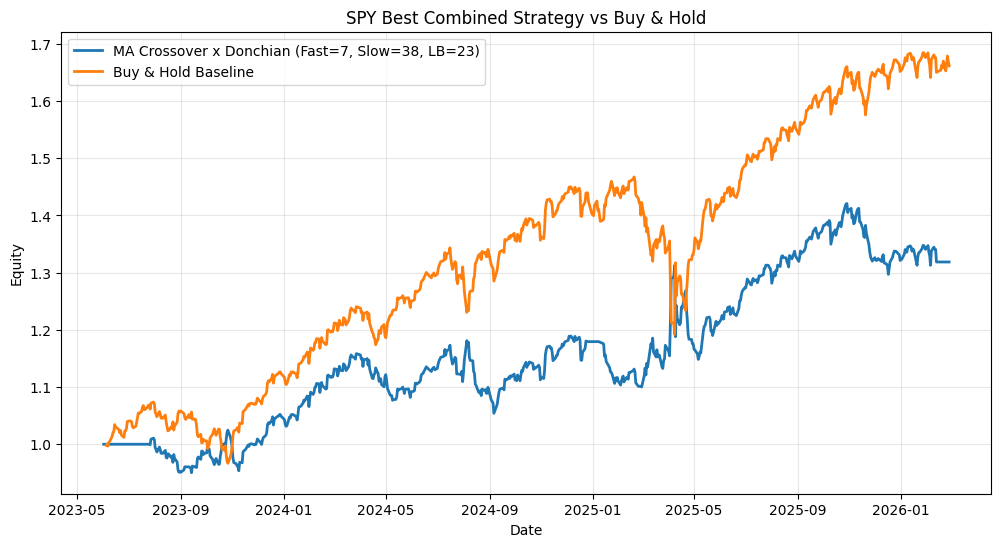

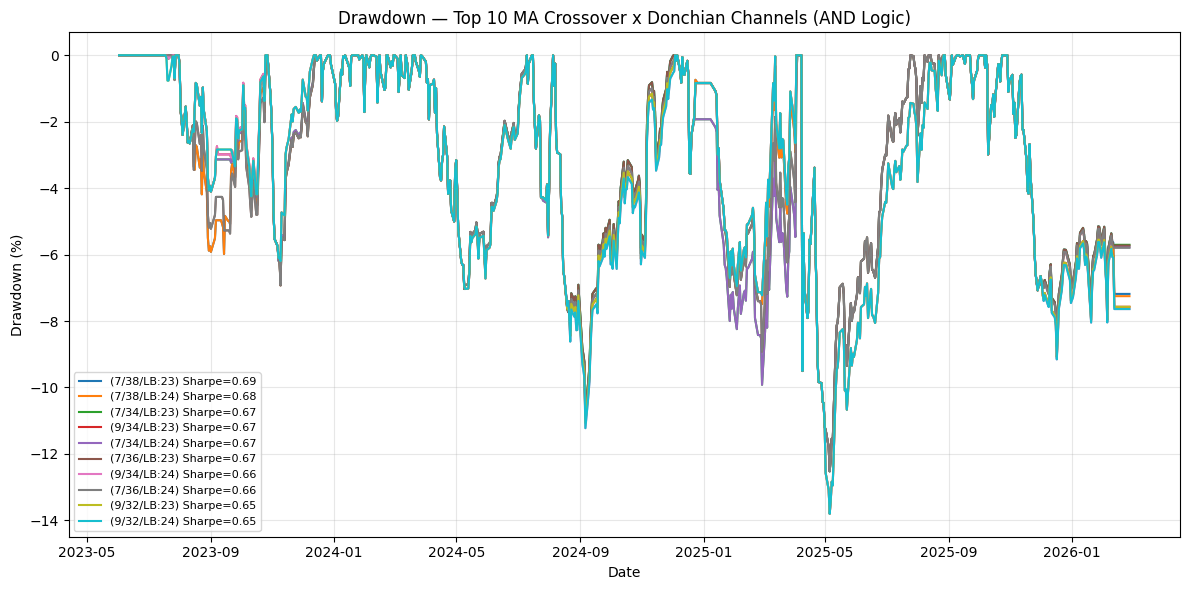

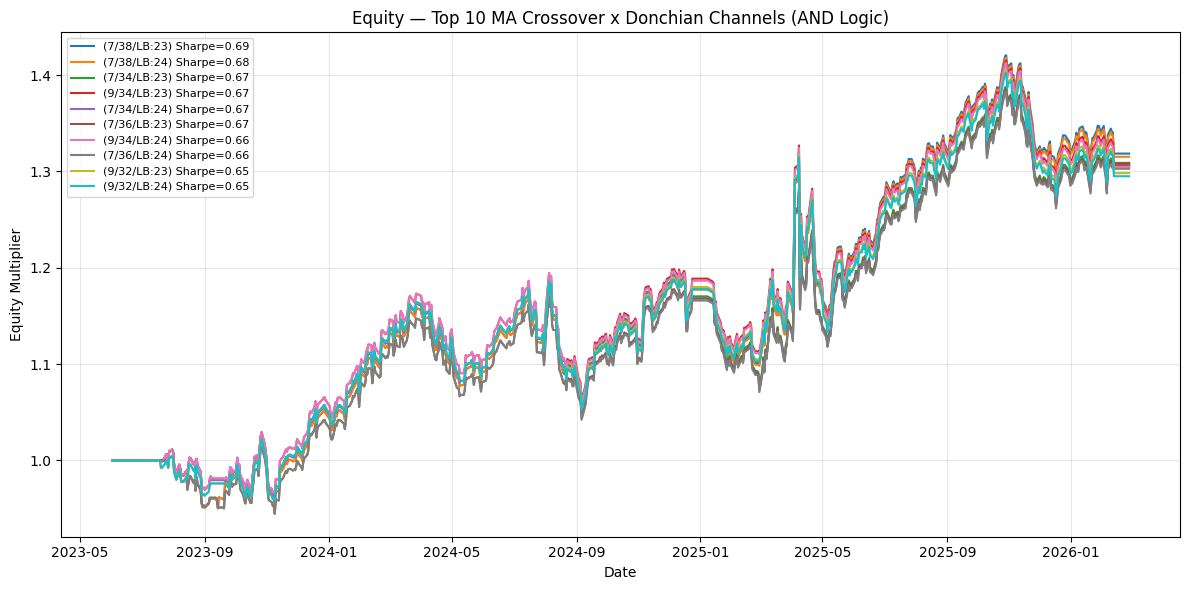

entries: 15, exits: 15

--- Top Trade Log Samples ---
  Entry Time  Exit Time Direction  Position  Entry Price  Exit Price  \
0 2023-07-27 2023-08-15      Long       1.0   437.051239  427.778900   
1 2023-08-16 2023-09-06     Short      -1.0   424.639740  430.995209   
2 2023-09-12 2023-09-18     Short      -1.0   430.773071  430.005005   
3 2023-09-20 2023-11-07     Short      -1.0   425.168274  423.510803   
4 2023-11-08 2024-04-15      Long       1.0   423.820953  492.464874   
5 2024-04-16 2024-05-09     Short      -1.0   491.566742  507.811371   
6 2024-05-09 2024-07-24      Long       1.0   507.811371  530.075562   
7 2024-07-29 2024-08-19     Short      -1.0   533.532959  548.076782   
8 2024-08-20 2024-12-26      Long       1.0   547.185669  592.741577   
9 2025-01-10 2025-01-22     Short      -1.0   572.189697  597.768677   

   Log Return   Return %  Duration Bars  Duration Days  Trend Strength  \
0   -0.021444  -2.121568             13             19        0.010504   
1   -

In [1]:
import pandas as pd
import numpy as np
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import log_returns
from quant_lab.strategies.sma_crossover import sma_crossover_position
from quant_lab.strategies.donchain_breakout import donchian_breakout_position
from quant_lab.engine.backtest import backtest_log_returns
from quant_lab.metrics.performance import evaluate_performance
from quant_lab.metrics.trades import generate_trade_log, evaluate_trades
import matplotlib.pyplot as plt

windows = [
    (fast, slow)
    for fast in range(5, 30, 2)
    for slow in range(20, 51, 2)
    if slow > fast
]

lookback = [
    lb for lb in range(5, 25, 1)
]

results = []
min_ratio = 1.5
periods_per_year = 252

for ticker in ["SPY"]:
    close = load_prices(ticker, "2023-06-01", "2026-03-01")["Close"]

    if isinstance(close, pd.DataFrame):
        close = close.iloc[1:, 0]

    # Calculate underlying asset log returns for baseline comparison
    asset_log = log_returns(close)
    buy_hold_equity = np.exp(asset_log.cumsum())

    # Pre-calculate baseline metrics to avoid re-running inside loops
    clean_asset_returns = asset_log.dropna()
    asset_mu = clean_asset_returns.mean()
    asset_sigma = clean_asset_returns.std(ddof=1)
    baseline_sharpe = float((asset_mu / asset_sigma) * np.sqrt(periods_per_year) if asset_sigma > 0 else np.nan)

    for fast, slow in windows:
        for lb in lookback:
            if slow / fast < min_ratio:
                continue  # Skip combinations that don't meet the minimum ratio requirement
            
            pos_ma       = sma_crossover_position(close, fast_window=fast, slow_window=slow)
            pos_donchian = donchian_breakout_position(close, lookback=lb)

            #  FIXED: Changed OR (|) logic to strict AND (&) logic
            position = np.where((pos_ma == 1)  & (pos_donchian == 1),  1,
                       np.where((pos_ma == -1) & (pos_donchian == -1), -1, 0))
            position = pd.Series(position, index=close.index, dtype=float)

            bt = backtest_log_returns(close, position, cost_per_trade=0.001)
            perf = evaluate_performance(bt, asset_log_returns=bt["log_return"])  # Pass asset returns for baseline comparison

            results.append({
                'Ticker':         ticker,
                'Fast':           fast,
                'Slow':           slow,
                'Lookback':       lb,
                'Return':         perf['Total Return'],
                'Strategy Sharpe': perf['Strategy Sharpe Ratio'],
                'Baseline Sharpe': baseline_sharpe,  # Added Baseline comparison here
                'Drawdown':       perf['Max Drawdown'],
                'Trades':         perf['Total Trades Executed'],
            })

# Build results table
# FIXED: Sorting by strategy sharpe
results_df = pd.DataFrame(results).sort_values('Strategy Sharpe', ascending=False)
print("\n--- All Results (sorted by Strategy Sharpe) ---")
print(results_df.head(10).to_string(index=False))

print("\n--- Filtered Results (Drawdown > -20%, Strategy Sharpe > 0.5, Positive Return) ---")
filtered = results_df[
    (results_df["Drawdown"] > -0.20) &
    (results_df["Strategy Sharpe"]   >  0.50) &
    (results_df["Return"]   >  0.00)
].sort_values("Strategy Sharpe", ascending=False)

if filtered.empty:
    print("No combinations met the filter criteria — consider relaxing the thresholds")
else:
    print(filtered.head(10).to_string(index=False))
# ---- END ----

# Best by Strategy Sharpe (from filtered if available, otherwise full results)
best_pool = filtered if not filtered.empty else results_df
best = best_pool.iloc[0]
print(f"\n--- Best Combination ---")
print(f"Ticker: {best['Ticker']}  Fast: {int(best['Fast'])}  Slow: {int(best['Slow'])} Lookback: {int(best['Lookback'])}")
print(f"Strat Sharpe: {best['Strategy Sharpe']:.3f}  Baseline Sharpe: {best['Baseline Sharpe']:.3f}  Return: {best['Return']:.3f}  Drawdown: {best['Drawdown']:.3f}")

# Plot the best
close = load_prices(best['Ticker'], "2023-06-01", "2026-03-01")["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[1:, 0]

pos_ma       = sma_crossover_position(close, fast_window=int(best['Fast']), slow_window=int(best['Slow']))
pos_donchian = donchian_breakout_position(close, lookback=int(best['Lookback']))

# Re-run confirmation logic cleanly
position = np.where((pos_ma == 1)  & (pos_donchian == 1),  1,
           np.where((pos_ma == -1) & (pos_donchian == -1), -1, 0))
position = pd.Series(position, index=close.index, dtype=float)

bt = backtest_log_returns(close, position, cost_per_trade=0.001)
buy_hold_equity = np.exp(log_returns(close).cumsum())

plt.figure(figsize=(12, 6))
plt.plot(bt["equity"], label=f"MA Crossover x Donchian (Fast={int(best['Fast'])}, Slow={int(best['Slow'])}, LB={int(best['Lookback'])})", linewidth=2)
plt.plot(buy_hold_equity, label="Buy & Hold Baseline", linewidth=2)
plt.title(f"{best['Ticker']} Best Combined Strategy vs Buy & Hold")
plt.ylabel("Equity")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Top 10 Drawdown Tracking Plot
top10 = filtered.head(10) if not filtered.empty else results_df.head(10)

plt.figure(figsize=(12, 6))
for _, row in top10.iterrows():
    #  FIXED: Uses row specifics instead of hardcoded best values
    pos_ma       = sma_crossover_position(close, fast_window=int(row['Fast']), slow_window=int(row['Slow']))
    pos_donchian = donchian_breakout_position(close, lookback=int(row['Lookback']))

    position = np.where((pos_ma == 1)  & (pos_donchian == 1),  1,
               np.where((pos_ma == -1) & (pos_donchian == -1), -1, 0))
    position = pd.Series(position, index=close.index, dtype=float)
    
    bt_row = backtest_log_returns(close, position, cost_per_trade=0.001)
    label = f"({int(row['Fast'])}/{int(row['Slow'])}/LB:{int(row['Lookback'])}) Sharpe={row['Strategy Sharpe']:.2f}"
    plt.plot(bt_row["drawdown"] * 100, label=label, linewidth=1.5)

plt.legend(fontsize=8)
plt.title("Drawdown — Top 10 MA Crossover x Donchian Channels (AND Logic)")
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Top 10 Equity Curves Plot
plt.figure(figsize=(12, 6))
for _, row in top10.iterrows():
    #  FIXED: Standardized logic to exact strategy match
    pos_ma       = sma_crossover_position(close, fast_window=int(row['Fast']), slow_window=int(row['Slow']))
    pos_donchian = donchian_breakout_position(close, lookback=int(row['Lookback']))

    position = np.where((pos_ma == 1)  & (pos_donchian == 1),  1,
               np.where((pos_ma == -1) & (pos_donchian == -1), -1, 0))
    position = pd.Series(position, index=close.index, dtype=float)
    
    bt_row = backtest_log_returns(close, position, cost_per_trade=0.001)
    label = f"({int(row['Fast'])}/{int(row['Slow'])}/LB:{int(row['Lookback'])}) Sharpe={row['Strategy Sharpe']:.2f}"
    plt.plot(bt_row["equity"], label=label, linewidth=1.5)

plt.legend(fontsize=8)
plt.title("Equity — Top 10 MA Crossover x Donchian Channels (AND Logic)")
plt.ylabel("Equity Multiplier")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final Trade Log Evaluations using the absolute best backtest
tl = generate_trade_log(bt, vol_window=20, trend_window=20)
print("\n--- Top Trade Log Samples ---")
print(tl.head(10))
print("\n--- Top Strategy Trade Metrics Evaluation ---")
print(evaluate_trades(tl))